### CUDA GPU Aided Training Setup

In [2]:
import torch, platform
print("torch:", torch.__version__)
print("cuda_available:", torch.cuda.is_available())
print("torch.version.cuda:", torch.version.cuda)   # None == CPU build
print("cudnn:", torch.backends.cudnn.version() if torch.cuda.is_available() else None)
if torch.cuda.is_available():
    print("device_count:", torch.cuda.device_count())
    print("name:", torch.cuda.get_device_name(0))
print("python:", platform.python_version())

torch: 2.6.0+cu124
cuda_available: True
torch.version.cuda: 12.4
cudnn: 90100
device_count: 1
name: NVIDIA GeForce RTX 3060
python: 3.10.11


In [ ]:
# CELL 1 — train BERT and return objects (model, tokenizer, val dataset, history)

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ---- Config ----
TRAIN_CSV = "data/twitter_training.csv"
VAL_CSV   = "data/twitter_validation.csv"
MODEL_NAME= "bert-base-uncased"
EPOCHS    = 3
BATCH     = 16
LR        = 2e-5
MAX_LEN   = 128

# Using GPU accelerates training significantly if available
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---- Load CSVs (no header: id, topic, label, text) ----
train_df = pd.read_csv(TRAIN_CSV, header=None, names=["id","topic","label","text"], keep_default_na=False)
val_df   = pd.read_csv(VAL_CSV,   header=None, names=["id","topic","label","text"], keep_default_na=False)


# ---- Data Preparation (the dataset does not contain null values or NaN values) ----
# Map labels to ints
# Derive the class vocabulary from training data only.
classes = sorted(train_df["label"].astype(str).unique())

# Create mapping dicts from label to id example: {"negative":0, "neutral":1, "positive":2} because models work with numeric class ids.
label2id = {c:i for i,c in enumerate(classes)}

# Inverse mapping from id to label example: {0:"negative", 1:"neutral", 2:"positive"}. why? because after the model predicts class ids, we may want to convert them back to labels for interpretation.
id2label = {i:c for c,i in label2id.items()}

# use the label2id mapping to create a new "y" column in both dataframes with the numeric class ids instead of string labels.
train_df["y"] = train_df["label"].map(label2id).astype(int)
val_df["y"]   = val_df["label"].map(label2id).astype(int)

num_labels = len(classes)
print("Label mapping:", label2id)

# ---- Dataset ----
class TxtDS(Dataset):
    def __init__(self, texts, labels, tokenizer):
        texts = [str(t) for t in texts.tolist()]

        # returns a dict with input_ids as number tensors, attention_mask all with the same length (padded/truncated to MAX_LEN)
        enc = tokenizer(texts, padding="max_length", truncation=True,
                        max_length=MAX_LEN, return_tensors="pt")
        
        """
        example:
        [
            (input_ids
            attention_mask)
        ]
        
        "Hello World" => [1, 1, 1, 0, 0]
        """
        
        self.enc = enc
        self.y = torch.tensor(labels.tolist(), dtype=torch.long)
    def __len__(self): return len(self.y)

    # Called by DataLoader to get a single item (input_ids, attention_mask, labels) at index i
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.y[i]
        return item

# ---- Train + Eval (returns model & tokenizer & val-dataset & history) ----
def train_and_eval(model_name):
    print(f"\n=== {model_name} ===")
    tok = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    tr_ds = TxtDS(train_df["text"], train_df["y"], tok)
    va_ds = TxtDS(val_df["text"],   val_df["y"],   tok)

    # calls __getitem__ on the dataset to get batches
    tr_loader = DataLoader(tr_ds, batch_size=BATCH, shuffle=True)
    va_loader = DataLoader(va_ds, batch_size=BATCH)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels, id2label=id2label, label2id=label2id
    ).to(device)
    optim = torch.optim.AdamW(model.parameters(), lr=LR)

    history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

    for epoch in range(1, EPOCHS+1):
        print(f"\n--- Epoch {epoch}/{EPOCHS} ---")
        # train
        model.train()
        tot_loss = tot_correct = tot_count = 0
        for batch in tr_loader:
            batch = {k: v.to(device) for k,v in batch.items()}
            optim.zero_grad()

            # forward pass to get model outputs
            out = model(**batch)

            # grab the loss from this pass and backpropagate to compute gradients
            loss = out.loss
            loss.backward()

            # apply an optimization step to update model weights
            optim.step()

            # compute metrics for reporting purposes
            preds = out.logits.argmax(dim=-1)
            n = batch["labels"].size(0)
            tot_loss   += loss.item() * n
            tot_correct+= (preds == batch["labels"]).sum().item()
            tot_count  += n
        train_loss = tot_loss / tot_count
        train_acc  = tot_correct / tot_count

        # validate
        model.eval()
        tot_loss = tot_correct = tot_count = 0
        with torch.no_grad():
            for batch in va_loader:
                batch = {k: v.to(device) for k,v in batch.items()}

                # forward pass
                out = model(**batch)
                loss = out.loss

                # multiply by batch size to get total loss
                preds = out.logits.argmax(dim=-1)
                n = batch["labels"].size(0)
                tot_loss   += loss.item() * n
                # compute number of correct predictions
                tot_correct+= (preds == batch["labels"]).sum().item()
                tot_count  += n
        val_loss = tot_loss / tot_count
        val_acc  = tot_correct / tot_count

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch}/{EPOCHS} | "
              f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f}")

    return history, model, tok, va_ds, id2label, num_labels, BATCH, device, MAX_LEN

# Run training and keep everything for the next cell
hist, model, tok, va_ds, id2label, num_labels, BATCH, device, MAX_LEN = train_and_eval(MODEL_NAME)


Device: cuda
Label mapping: {'Irrelevant': 0, 'Negative': 1, 'Neutral': 2, 'Positive': 3}

=== bert-base-uncased ===


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Epoch 1/3 ---
Epoch 1/3 | train_loss=0.6988 acc=0.7265 | val_loss=0.1882 acc=0.9460

--- Epoch 2/3 ---
Epoch 2/3 | train_loss=0.2387 acc=0.9123 | val_loss=0.1388 acc=0.9580

--- Epoch 3/3 ---
Epoch 3/3 | train_loss=0.1520 acc=0.9409 | val_loss=0.1620 acc=0.9620


Saved fine-tuned model + tokenizer to: bert_finetuned

=== Validation Metrics ===
Accuracy: 0.96

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.99      0.91      0.95       172
    Negative       0.98      0.96      0.97       266
     Neutral       0.92      0.98      0.95       285
    Positive       0.97      0.96      0.97       277

    accuracy                           0.96      1000
   macro avg       0.97      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000

Confusion Matrix (rows=true, cols=pred):
[[157   3   9   3]
 [  0 256   9   1]
 [  1   1 280   3]
 [  0   2   8 267]]


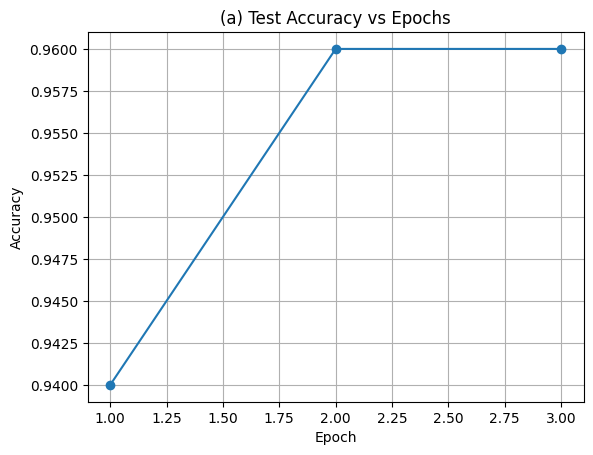

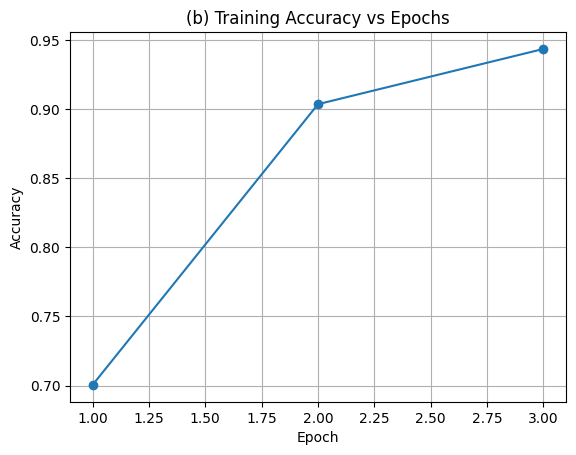

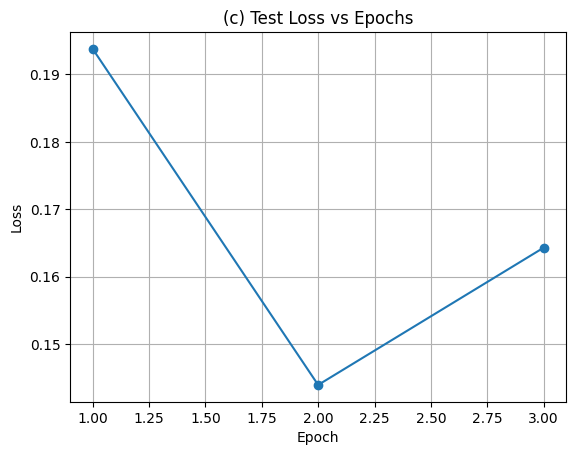

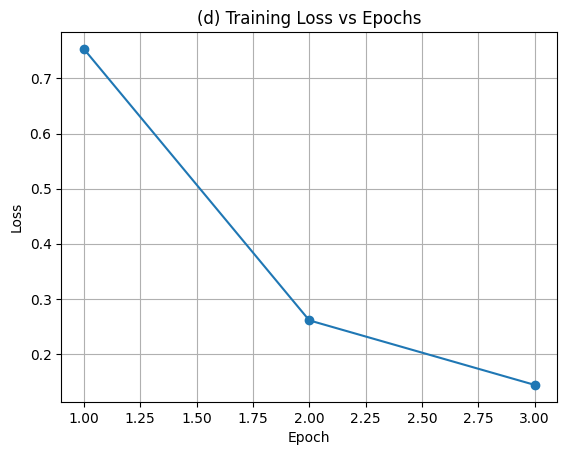

In [ ]:
# save model/tokenizer, compute validation metrics, and plot curves
# pip install scikit-learn matplotlib numpy  (if not already installed)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

SAVE_DIR = "bert_finetuned"   # where to save

# 1) Save fine-tuned model + tokenizer
model.save_pretrained(SAVE_DIR)
tok.save_pretrained(SAVE_DIR)
print(f"Saved fine-tuned model + tokenizer to: {SAVE_DIR}")

# 2) Validation metrics (confusion matrix, precision/recall/F1)
va_loader = DataLoader(va_ds, batch_size=BATCH, shuffle=False)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in va_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits
        all_preds.append(logits.argmax(dim=-1).cpu().numpy())
        all_labels.append(batch["labels"].cpu().numpy())
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print("\n=== Validation Metrics ===")
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=[id2label[i] for i in range(num_labels)],
    zero_division=0
))
print("Confusion Matrix (rows=true, cols=pred):")
print(confusion_matrix(all_labels, all_preds))

# 3) Plots (learning curves from hist)
epochs = range(1, len(hist["val_acc"])+1)
plt.figure(); plt.plot(list(epochs), hist["val_acc"], marker="o"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("(a) Validation Accuracy vs Epoch"); plt.grid(True); plt.show()
plt.figure(); plt.plot(list(epochs), hist["train_acc"], marker="o"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("(b) Training Accuracy vs Epoch"); plt.grid(True); plt.show()
plt.figure(); plt.plot(list(epochs), hist["val_loss"], marker="o"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("(c) Validation Loss vs Epoch"); plt.grid(True); plt.show()
plt.figure(); plt.plot(list(epochs), hist["train_loss"], marker="o"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("(d) Training Loss vs Epoch"); plt.grid(True); plt.show()


In [ ]:
# Save Metrics in a CSV File

import pandas as pd

# Convert history dictionary to a table
metrics_df = pd.DataFrame({
    "epoch": range(1, len(hist["train_loss"]) + 1),
    "train_loss": hist["train_loss"],
    "train_acc":  hist["train_acc"],
    "val_loss":   hist["val_loss"],
    "val_acc":    hist["val_acc"]
})

# File name (change if you want)
METRICS_FILE = "bert_metrics.csv"

metrics_df.to_csv(METRICS_FILE, index=False)

print(f"Saved metrics to {METRICS_FILE}")
print(metrics_df)

Saved metrics to bert_metrics.csv
   epoch  train_loss  train_acc  val_loss  val_acc
0      1    0.753683   0.700490  0.193773     0.94
1      2    0.261004   0.903511  0.143960     0.96
2      3    0.143828   0.943467  0.164303     0.96
